In [7]:
import warnings

In [9]:
warnings.filterwarnings("ignore")

In [11]:
import pandas as pd

In [13]:
import numpy as np

In [15]:
from sklearn.datasets import load_iris

In [17]:
from sklearn.preprocessing import StandardScaler

In [20]:
raw_iris = load_iris()

In [22]:
features = raw_iris.feature_names

In [24]:
X_raw = raw_iris.data

In [26]:
y_true = raw_iris.target

In [28]:
scaler = StandardScaler()

In [30]:
X_scaled = scaler.fit_transform(X_raw)

In [32]:
iris_df = pd.DataFrame(data = X_scaled, columns=features)

In [34]:
iris_df['species_id'] = y_true

In [36]:
species_map = {i: name for i, name in enumerate(raw_iris.target_names)}

In [38]:
iris_df['species_name'] = iris_df['species_id'].map(species_map)

In [40]:
print("Standardized dataset dimensions:",X_scaled.shape)

Standardized dataset dimensions: (150, 4)


In [42]:
print("\nFirst 3 rows of standardized dataset:")


First 3 rows of standardized dataset:


In [44]:
print(iris_df.head(3))

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.900681          1.019004          -1.340227         -1.315444   
1          -1.143017         -0.131979          -1.340227         -1.315444   
2          -1.385353          0.328414          -1.397064         -1.315444   

   species_id species_name  
0           0       setosa  
1           0       setosa  
2           0       setosa  


In [46]:
cov_matrix = np.cov(X_scaled.T)

In [48]:
print("Covariance Matrix:\n",cov_matrix)

Covariance Matrix:
 [[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


In [50]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [52]:
print("\nEigenvalues (Variance components):\n",eigenvalues)


Eigenvalues (Variance components):
 [2.93808505 0.9201649  0.14774182 0.02085386]


In [54]:
print("\nEigenvectors (Principal Axes:\n",eigenvectors)


Eigenvectors (Principal Axes:
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


In [56]:
from sklearn.decomposition import PCA

In [58]:
pca_model = PCA(n_components = 2, random_state=42)

In [60]:
X_pca = pca_model.fit_transform(X_scaled)

In [62]:
pca_df = pd.DataFrame(data=X_pca, columns = ['PC_1','PC_2'])

In [64]:
pca_df['species_name'] = iris_df['species_name']

In [66]:
print("Transformed PCA spane dimensions:",X_pca.shape)

Transformed PCA spane dimensions: (150, 2)


In [68]:
print("\nFirst 3 projected coordinated:")


First 3 projected coordinated:


In [70]:
print(pca_df.head(3))

       PC_1      PC_2 species_name
0 -2.264703  0.480027       setosa
1 -2.080961 -0.674134       setosa
2 -2.364229 -0.341908       setosa


In [72]:
import matplotlib.pyplot as plt

In [74]:
import seaborn as sns

In [78]:
plt.figure(figsize=(6,4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='PC_1', ylabel='PC_2'>

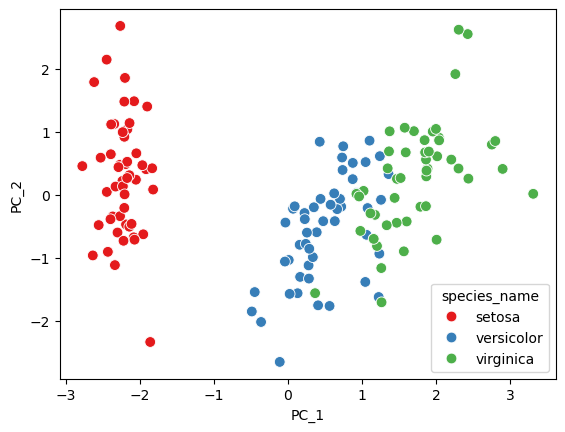

In [80]:
sns.scatterplot(data=pca_df, x='PC_1',y='PC_2', hue = 'species_name', palette='Set1', s=60)

Text(0.5, 1.0, '2-Component PCA Projection ofIris Dataset')

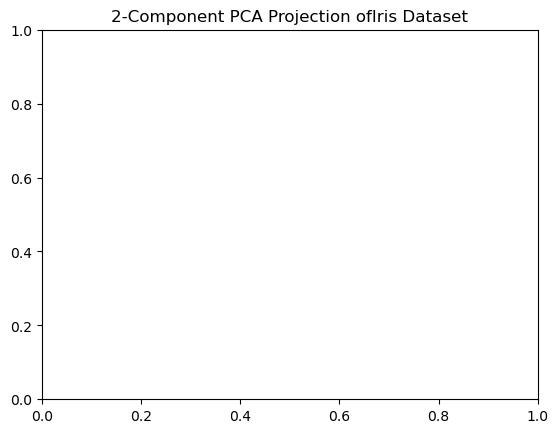

In [82]:
plt.title("2-Component PCA Projection ofIris Dataset")

Text(0.5, 0, 'Principal Component 1 (PC1)')

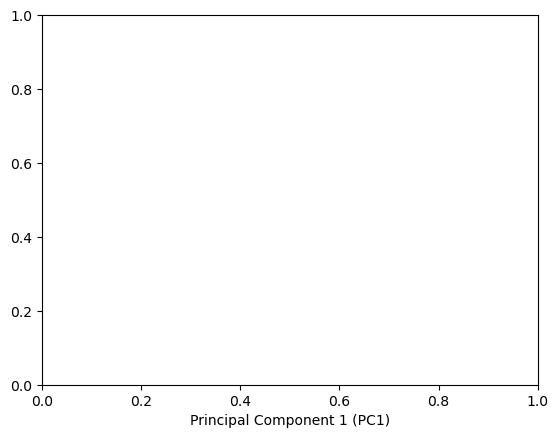

In [84]:
plt.xlabel("Principal Component 1 (PC1)")

Text(0, 0.5, 'Principal Component 2 (PC2)')

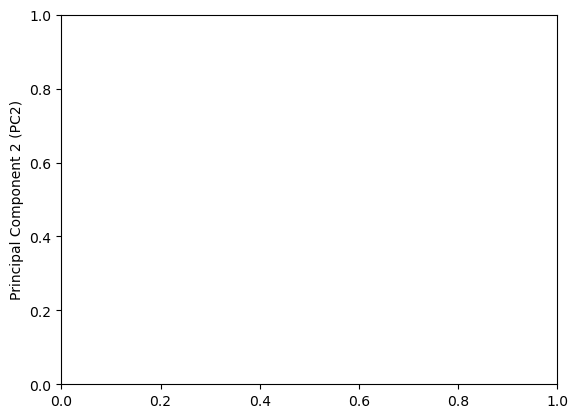

In [86]:
plt.ylabel("Principal Component 2 (PC2)")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


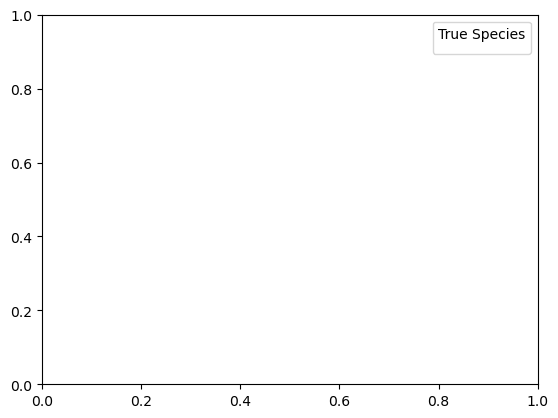

In [88]:
plt.legend(title='True Species')

In [90]:
plt.show()

In [92]:
explained_variance = pca_model.explained_variance_ratio_

In [94]:
cumulative_variance = np.sum(explained_variance)

In [96]:
print("Explained Variance per Component:")

Explained Variance per Component:


In [100]:
for i, var in enumerate(explained_variance):
    print(f" PC{i+1}: {var*100:.2f}%")

 PC1: 72.96%
 PC2: 22.85%


In [102]:
print(f"\nTotal cumulative Variance Retained by 2 Compnents: {cumulative_variance*100:.2f}%")


Total cumulative Variance Retained by 2 Compnents: 95.81%


In [104]:
import numpy as np

In [106]:
import pandas as pd

In [108]:
import matplotlib.pyplot as plt

In [110]:
from sklearn.datasets import load_iris

In [112]:
from sklearn.model_selection import train_test_split

In [114]:
from sklearn.preprocessing import StandardScaler

In [116]:
from sklearn.decomposition import PCA

In [118]:
from sklearn.linear_model import LogisticRegression

In [120]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [122]:
iris = load_iris()

In [124]:
X = iris.data

In [126]:
y=iris.target

In [128]:
feature_names = iris.feature_names

In [130]:
target_names = iris.target_names

In [132]:
print("Dataset Shape:",X.shape)

Dataset Shape: (150, 4)


In [134]:
print("Feature:",feature_names)

Feature: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [136]:
print("Classes:",target_names)

Classes: ['setosa' 'versicolor' 'virginica']
